# 03 Many assets: factors

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/03_many_assets_factors.ipynb)

**The question.** Notebooks 01 and 02 worked on six assets. An asset manager's
universe has dozens or hundreds: sectors, countries, styles, maturities,
commodities. With $N$ assets there are $N(N-1)/2$ pairs, 2,628 for the 73 ETFs
below. A copula family selected per pair from 230 months is mostly noise, as
notebook 02 measured; a C-vine with 72 trees would take hours to calibrate;
and the 2,628 correlations themselves, estimated from 230 months, are not
2,628 independent facts. How does the process scale?

**The answer in one paragraph.** Through factors. A few common sources of
return, seven here, carry the dependence. Each asset is a set of exposures
(betas) to the factors it is allowed to load on, stated a priori from what the
asset is, plus a residual of its own, and the residuals are treated as
independent of each other and of the factors. The generators of notebooks 01
and 02 then run on the seven factors instead of the 73 assets: each produces
a table of synthetic factor months, and the factor model turns every row of
that table into 73 asset returns by arithmetic. Targets, fit, check, use, with
one more assumption to check.

**What you need before this notebook.** Notebooks 01 and 02: targets, the two
generators, the exceedance profile.

**What this notebook adds.** The seven factors and how they are built from
public data; the a priori exposure table; the factor model and its
estimation; the independence assumption and how to read its failures;
scenarios and views on many assets from scenarios and views on seven factors.

Runtime: about 8 minutes.

## Import

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

from cvinemarketgen import (load_etf_monthly, load_factor_data, load_daily_returns, Targets, FleishmanMarket, CVineMarket, FactorModel,
                            exceedance_curve, iid_tests)
from scipy import stats
import seaborn as sns
from scipy import stats
normal_scores = lambda v: pd.Series(stats.norm.ppf(stats.rankdata(v) / (len(v) + 1)), index=getattr(v, "index", None))   # the copula scale
import pyvinecopulib as pv
from cvinemarketgen.copulas import CopulaTools
_ct = CopulaTools()

cvinemarketgen 0.3.0


## The universe

Seventy-three ETFs with monthly total returns since June 2007: nine U.S.
sectors, U.S. size and style funds, developed and emerging country funds,
Treasury, corporate, high-yield and inflation-linked bond funds, commodities,
real estate and a few industry funds. The loader aligns them on their common
months; the factors of the next section end in July 2026, so the sample is 230
months. The first cell counts what a pairwise approach would face; the second
computes the eigenvalues of the sample correlation matrix,
$\hat\Sigma = \mathbf V \boldsymbol\Lambda \mathbf V'$, whose leading
eigenvalues measure how much of the universe's variance a few common
directions carry, $\sum_{k \le K} \lambda_k / \sum_k \lambda_k$.

In [2]:
tickers = "XLF XLK XLE XLV XLI XLP XLU XLY XLB SPY IWM MDY IWD IWF IWN IWO QQQ DIA VTV VUG IJH IJR EFA EEM VWO EWJ EWG EWU EWC EWA EWZ EWY EWT EWH EWS EWQ EWL EWP EWI EWM EWW EWD EWN EPP FXI TLT IEF SHY LQD HYG TIP AGG BND MBB IEI TLH GLD SLV USO DBC GDX VNQ IYR RWR KBE KRE XHB ITB SMH IBB XRT PFF XOP".split()
groups = {"U.S. sectors": tickers[:9], "U.S. size and style": tickers[9:22], "countries": tickers[22:45], "bonds": tickers[45:56], "commodities": tickers[56:61], "real estate and industries": tickers[61:]}
R = load_etf_monthly(tickers, start="2007-04", cache=os.path.join(ROOT, "data", "etf_cache_universe.csv"))
F = load_factor_data(cache=os.path.join(ROOT, "data", "factors_cache.csv"))
idx = R.index.intersection(F.index); R, F = R.loc[idx], F.loc[idx]
N = R.shape[1]
print(f"{N} assets, {len(idx)} months ({idx.min()} to {idx.max()}), {N * (N - 1) // 2} pairs")
pd.Series({g: len(v) for g, v in groups.items()}, name="assets per group").to_frame().T

ETF returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/etf_cache_universe.csv: 232 months, 2007-06 to 2026-09
factor data read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/factors_cache.csv: 244 months, 2006-04 to 2026-07
73 assets, 230 months (2007-06 to 2026-07), 2628 pairs


,U.S. sectors,U.S. size and style,countries,bonds,commodities,real estate and industries
assets per group,9,13,23,11,5,12


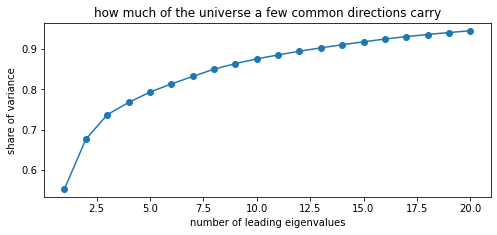

share of variance in the first 1, 3, 7 eigenvalues: [0.553, 0.737, 0.832]


In [3]:
ev = np.linalg.eigvalsh(R.corr().values)[::-1]
share = pd.Series(np.cumsum(ev) / ev.sum(), index=range(1, N + 1))
fig, ax = plt.subplots(figsize=(8, 3.2)); share.iloc[:20].plot(ax=ax, marker="o"); ax.set_xlabel("number of leading eigenvalues"); ax.set_ylabel("share of variance"); ax.set_title("how much of the universe a few common directions carry"); plt.show()
print("share of variance in the first 1, 3, 7 eigenvalues:", share.loc[[1, 3, 7]].round(3).tolist())

## The seven factors

The common sources of return are given an economic name rather than extracted
statistically, so that a view can be stated on them and an asset's exposures
can be written down before the data are seen. Seven monthly excess returns,
built from public data by `load_factor_data`:

| Factor | Construction | Source |
|---|---|---|
| Equity DM | developed-market excess return, Mkt minus RF | Fama-French |
| Equity EM | emerging minus developed excess return | Fama-French |
| Real premia | carry minus 8 times the change of the 10-year TIPS real yield | FRED |
| Inflation | carry plus 8 times the change of the 10-year breakeven | FRED |
| Credit | carry minus 10 times the change of the Baa minus 10-year spread | FRED |
| Commodity | DBC total return minus the risk-free rate | Yahoo Finance |
| Small cap | U.S. small minus big, SMB | Fama-French |

The three yield-based factors are long-short positions on a daily FRED series
$y_t$ (a yield or a spread in percent), taken at the month end and divided by
100, with a fixed duration $D$,

$$
f_t = \frac{y_{t-1}}{12} + s\, D\, (y_t - y_{t-1}),
$$

the carry over the month plus the price effect of the yield change, with
$s = -1$ for a long bond position (it loses when the yield rises) and $s = +1$
for the breakeven position (long TIPS, short nominal). Notebook 07 replaces
this duration approximation by exact pricing from a simulated curve. The
table gives the factors' sample moments, the mean and volatility annualized
(mean times 12, volatility times $\sqrt{12}$), skewness and kurtosis as they
are; the kurtosis, above 5 for real premia, inflation and credit, is the tails
the generators will carry.

In [4]:
fm_t = Targets.from_history(F).moments
print(F.shape[0], "months")
pd.DataFrame({"mean (% a year)": fm_t["mean"] * 1200, "vol (% a year)": fm_t["vol"] * np.sqrt(12) * 100, "skewness": fm_t["skew"], "kurtosis": fm_t["kurt"]}).round(2)

230 months


,mean (% a year),vol (% a year),skewness,kurtosis
Equity DM,7.60,16.15,-0.61,4.55
Equity EM,-1.34,10.85,0.02,2.98
Real premia,0.77,6.31,-0.63,5.34
Inflation,2.02,4.80,0.12,9.27
Credit,2.48,8.45,-1.86,16.71
Commodity,2.28,19.16,-0.54,4.88
Small cap,-0.47,8.75,0.31,2.96


## A priori exposures

Regressing every asset on every factor lets the data assign a commodity beta
to a utility or a small-cap beta to a Treasury fund, from 230 months, and the
noise in those betas becomes noise in the synthetic data. The exposure table
states, before any estimation, which factors each asset may load on, from
what the asset is: every equity fund on Equity DM; small and mid caps also on
Small cap; emerging markets also on Equity EM; energy, materials and the
commodity exporters also on Commodity; financials, utilities, real estate and
preferreds on Real premia and Credit as well, being rate and spread sensitive;
nominal bond funds on Real premia and Inflation (long the real yield, short
the breakeven), the aggregates and corporates also on Credit; precious metals
on Real premia, Inflation and Commodity. The dictionary below is that table;
the model estimates only the betas it allows and sets the others to zero.

In [5]:
E = {}
for a in ["XLK", "XLV", "XLI", "XLP", "XLY", "SPY", "DIA", "QQQ", "IWD", "IWF", "VTV", "VUG", "EFA", "EWJ", "EWG", "EWU", "EWQ", "EWL", "EWP", "EWI", "EWD", "EWN", "EWH", "EWS", "EPP"]:
    E[a] = ["Equity DM"]
for a in ["XLE", "XOP", "XLB", "EWA", "EWC"]:
    E[a] = ["Equity DM", "Commodity"]
E["XLF"] = ["Equity DM", "Real premia", "Credit"]
for a in ["KBE", "KRE"]:
    E[a] = ["Equity DM", "Real premia", "Credit", "Small cap"]
for a in ["XLU", "VNQ", "IYR", "RWR", "PFF", "XHB", "ITB"]:
    E[a] = ["Equity DM", "Real premia", "Credit"]
for a in ["SMH", "IBB", "XRT", "IWM", "IJR", "IWN", "IWO", "MDY", "IJH"]:
    E[a] = ["Equity DM", "Small cap"]
for a in ["EEM", "VWO", "EWY", "EWT", "FXI", "EWM"]:
    E[a] = ["Equity DM", "Equity EM"]
for a in ["EWZ", "EWW"]:
    E[a] = ["Equity DM", "Equity EM", "Commodity"]
for a in ["TLT", "IEF", "IEI", "TLH", "SHY", "TIP"]:
    E[a] = ["Real premia", "Inflation"]
for a in ["AGG", "BND", "MBB", "LQD"]:
    E[a] = ["Real premia", "Inflation", "Credit"]
E["HYG"] = ["Real premia", "Inflation", "Credit", "Equity DM"]
for a in ["GLD", "SLV"]:
    E[a] = ["Real premia", "Inflation", "Commodity"]
E["GDX"] = ["Real premia", "Inflation", "Commodity", "Equity DM"]
for a in ["DBC", "USO"]:
    E[a] = ["Commodity", "Inflation"]
assert set(E) == set(tickers), set(tickers) - set(E)
expo = pd.DataFrame(False, index=tickers, columns=F.columns)
for a, fs in E.items(): expo.loc[a, fs] = True
print("betas estimated:", int(expo.values.sum()), "of", expo.size, "possible")
expo.astype(int).T

betas estimated: 145 of 511 possible


,XLF,XLK,XLE,XLV,XLI,XLP,XLU,XLY,XLB,SPY,...,RWR,KBE,KRE,XHB,ITB,SMH,IBB,XRT,PFF,XOP
Equity DM,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Equity EM,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Real premia,1,0,0,0,0,0,1,0,0,0,...,1,1,1,1,1,0,0,0,1,0
Inflation,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Credit,1,0,0,0,0,0,1,0,0,0,...,1,1,1,1,1,0,0,0,1,0
Commodity,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
Small cap,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,1,1,1,0,0


## The factor model

Asset $j$'s return in month $t$ is its exposures times the factors plus a
residual,

$$
r_{j,t} = \alpha_j + \sum_{k \in \mathcal K_j} \beta_{jk}\, f_{k,t} + e_{j,t}, \qquad j = 1, \dots, N,
$$

with $\mathcal K_j$ the factors the exposure table allows for asset $j$,
estimated by ordinary least squares asset by asset: with $\mathbf X_j$ the
$T \times (|\mathcal K_j| + 1)$ matrix of a constant and the allowed factors,
$(\hat\alpha_j, \hat{\boldsymbol\beta}_j') = (\mathbf X_j'\mathbf X_j)^{-1} \mathbf X_j' \mathbf r_j$,
Newey-West standard errors (Bartlett weights, $\lfloor 4(T/100)^{2/9} \rfloor$
lags) for the $t$-statistics, $R_j^2 = 1 - \sum_t \hat e_{j,t}^2 / \sum_t (r_{j,t} - \bar r_j)^2$,
and the residual volatility $\hat\sigma_{e_j}$ with $T - |\mathcal K_j| - 1$
degrees of freedom. Each residual then gets a Johnson SU marginal fitted to its
skewness and kurtosis, as the assets did in notebook 02.

The model's covariance of the assets is
$\boldsymbol\Sigma = \mathbf B\, \boldsymbol\Sigma_f\, \mathbf B' + \mathbf D$,
with $\mathbf B$ the $N \times K$ matrix of betas (zero where the table says
so), $\boldsymbol\Sigma_f$ the factors' covariance and $\mathbf D$ the
*diagonal* matrix of residual variances: the dependence between two assets
goes through the factors only, because the residuals are assumed independent
of each other and of the factors. That is the one assumption the factor route
adds, and a later section checks it. `FactorModel.fit` does the estimation;
the report shows a few assets, then the distribution of $R^2$ across the 73.

In [6]:
fm = FactorModel(R, F, exposures=E).fit()
show = ["SPY", "XLF", "EWZ", "TLT", "HYG", "GLD", "XLU"]
display(fm.report.loc[show, ["alpha"] + fm.factors + ["R2", "resid vol"]].round(3))
print("R2 across the 73 assets, quantiles:"); fm.r2.quantile([0, 0.1, 0.25, 0.5, 0.75, 0.9, 1]).round(2).to_frame("R2").T

,alpha,Equity DM,Equity EM,Real premia,Inflation,Credit,Commodity,Small cap,R2,resid vol
SPY,0.004,0.930,0.000,0.000,0.000,0.000,0.000,0.0,0.933,0.012
XLF,-0.001,1.303,0.000,-0.852,0.000,-0.145,0.000,0.0,0.732,0.034
EWZ,0.000,0.970,1.029,0.000,0.000,0.000,0.418,0.0,0.586,0.062
TLT,0.006,0.000,0.000,1.765,-2.092,0.000,0.000,0.0,0.886,0.014
HYG,0.001,0.363,0.000,0.377,-0.210,0.360,0.000,0.0,0.667,0.017
GLD,0.008,0.000,0.000,1.344,-0.603,0.000,0.300,0.0,0.308,0.042
XLU,0.004,0.289,0.000,0.704,0.000,0.226,0.000,0.0,0.311,0.036


R2 across the 73 assets, quantiles:


,0.00,0.10,0.25,0.50,0.75,0.90,1.00
R2,0.29,0.47,0.58,0.73,0.86,0.93,1.0


Read the report against the exposure table: every zero is a zero the table
imposed, every other beta is estimated. SPY is Equity DM alone, beta 0.93,
$R^2 = 0.93$. XLF has 1.30 on equity and $-0.85$ on Real premia, a long-TIPS
position: banks earn more when real yields rise; its credit beta is small.
EWZ, Brazil, loads on both equity factors (0.97 and 1.03) and on commodities
(0.42), $R^2 = 0.59$. TLT is 1.77 on Real premia and $-2.09$ on Inflation, a
long nominal bond being long the real yield and short the breakeven,
$R^2 = 0.89$. HYG splits between equity, real premia and credit. Gold and
utilities are the least explained (0.31): their drivers are only partly among
the seven. Across the 73 assets the median $R^2$ is 0.73 with an interquartile
range of 0.58 to 0.86, against 0.78 when every asset is regressed on every
factor: five points of $R^2$ is what the a priori table gives up, and it is
the part of the unrestricted fit that was noise, a commodity beta on a
utility or a small-cap beta on a Treasury fund estimated from 230 months.
The alphas are a few basis points a month, within their standard errors.

## Check the assumption: residual correlations

If the residuals were independent, their sample correlations would be noise
around zero (standard error about $1/\sqrt{T} = 0.07$). The table lists the
largest residual correlations in absolute value. Read the names. Some pairs
are two funds on the same index (IJH and MDY are both the S&P MidCap 400; IYR,
RWR and VNQ are all U.S. REITs; IWF and VUG, IWD and VTV are the same growth
and value indices from two providers): their residuals are one residual, and
the remedy is to hold one fund per index, which the next cell does. The
others (banks KBE and KRE, homebuilders ITB and XHB, Australia and the
Pacific fund) share a source of return that the seven factors do not name: a
banks factor, a housing factor. The remedy for those is not in the model but
in the factor list: add the specialized factor as one more column of the
factor table, and the framework takes it as it takes the seven. The
notebook keeps the seven and reads the residual correlation that remains as
the price of that choice; the last table gives the implied against the sample
correlation of the assets, whose root mean squared difference measures what
seven factors and independent residuals leave out.

In [7]:
rc = fm.resid.corr()
pairs = rc.stack(); pairs = pairs[pairs.index.get_level_values(0) < pairs.index.get_level_values(1)]
print(f"residual correlations: mean |.| {pairs.abs().mean():.3f}, 95th percentile |.| {np.quantile(pairs.abs(), 0.95):.2f}, standard error of a zero correlation {1 / np.sqrt(len(R)):.2f}")
pairs.abs().sort_values(ascending=False).head(12).round(2).to_frame("|residual correlation|")

residual correlations: mean |.| 0.155, 95th percentile |.| 0.50, standard error of a zero correlation 0.07


,,|residual correlation|
IJH,MDY,1.00
IYR,VNQ,0.99
RWR,VNQ,0.99
IYR,RWR,0.98
IWF,VUG,0.96
ITB,XHB,0.96
IWD,VTV,0.95
KBE,KRE,0.89
QQQ,XLK,0.89
IJR,IWN,0.88


In [8]:
same_index = [("IJH", "MDY"), ("IYR", "VNQ"), ("RWR", "VNQ"), ("IWF", "VUG"), ("IWD", "VTV")]
drop = ["IJH", "IYR", "RWR", "VUG", "VTV"]                     # one fund per index: MDY, VNQ, IWF, IWD kept
R = R.drop(columns=drop); N = R.shape[1]; E = {a: fs for a, fs in E.items() if a in R.columns}
fm = FactorModel(R, F, exposures=E).fit()
rc = fm.resid.corr(); pairs = rc.stack(); pairs = pairs[pairs.index.get_level_values(0) < pairs.index.get_level_values(1)]
print(f"{N} assets kept; residual correlations now: mean |.| {pairs.abs().mean():.3f}; the largest that remain:", pairs.abs().nlargest(4).round(2).to_dict())
Sigma_f = F.cov().values; B = fm.beta.values; D = np.diag(fm.resid_vol.values ** 2)
Sigma = B @ Sigma_f @ B.T + D; implied = Sigma / np.sqrt(np.outer(np.diag(Sigma), np.diag(Sigma)))
diff = (implied - R.corr().values)[np.triu_indices(N, 1)]
print(f"implied versus sample correlation of the assets: RMSE {np.sqrt((diff ** 2).mean()):.3f}, max |.| {np.abs(diff).max():.2f}")

68 assets kept; residual correlations now: mean |.| 0.148; the largest that remain: {('ITB', 'XHB'): 0.96, ('KBE', 'KRE'): 0.89, ('QQQ', 'XLK'): 0.89, ('IJR', 'IWN'): 0.88}
implied versus sample correlation of the assets: RMSE 0.085, max |.| 0.53


## Step 1: targets, on the factors

From here the four steps run on the seven factors, not on the assets. The
targets are the factors' moments and correlations: 28 numbers for the moments
and 21 correlations, in place of the 292 moments and 2,628 correlations of the
assets. The table gives, per factor, the arithmetic mean and the volatility
annualized (the generator works on the monthly numbers, these are the same
numbers scaled by 12 and $\sqrt{12}$ to read) and the correlation matrix. The
factor model will carry them to the assets in Step 3.

In [9]:
t = Targets.from_history(F)
pd.concat([(t.mean * 1200).rename("mean (% a year)"), (t.vol * np.sqrt(12) * 100).rename("vol (% a year)"), t.corr], axis=1).round(2)

,mean (% a year),vol (% a year),Equity DM,Equity EM,Real premia,Inflation,Credit,Commodity,Small cap
Equity DM,7.60,16.15,1.00,0.09,0.31,0.52,0.61,0.51,0.28
Equity EM,-1.34,10.85,0.09,1.00,0.13,0.18,0.22,0.24,-0.02
Real premia,0.77,6.31,0.31,0.13,1.00,0.21,-0.01,0.11,0.01
Inflation,2.02,4.80,0.52,0.18,0.21,1.00,0.57,0.58,0.20
Credit,2.48,8.45,0.61,0.22,-0.01,0.57,1.00,0.45,0.25
Commodity,2.28,19.16,0.51,0.24,0.11,0.58,0.45,1.00,0.10
Small cap,-0.47,8.75,0.28,-0.02,0.01,0.20,0.25,0.10,1.00


## Step 2a: the Fleishman generator on the factors

The generator of notebook 01, fitted on the seven factor targets: a cubic of a
normal per factor, Gaussian dependence calibrated to the 21 correlations. It
simulates 25,000 synthetic months of the seven factors, a table of 25,000 rows
by 7 columns; the diagnostics check that table against the targets, as in
notebook 01. Nothing about the assets has been used yet.

In [10]:
fl = FleishmanMarket(t).fit()
Ffl = fl.simulate(25000, seed=1)
print(fl, "| factor scenarios:", Ffl.shape)
fl.diagnostics(Ffl).summary(digits=4);

FleishmanMarket(7 assets, fitted) | factor scenarios: (25000, 7)
25000 simulated observations (returns layer)
             mean target  mean simulated  mean diff  vol target  vol simulated  vol diff  skew target  skew simulated  skew diff  kurt target  kurt simulated  kurt diff
Equity DM         0.0063          0.0063       -0.0      0.0466         0.0466       0.0      -0.6119         -0.6119    -0.0000       4.5483          4.5489     0.0005
Equity EM        -0.0011         -0.0011        0.0      0.0313         0.0313       0.0       0.0225          0.0225     0.0000       2.9803          2.9805     0.0002
Real premia       0.0006          0.0006        0.0      0.0182         0.0182       0.0      -0.6297         -0.6297    -0.0000       5.3391          5.3398     0.0007
Inflation         0.0017          0.0017        0.0      0.0139         0.0139       0.0       0.1216          0.1216     0.0000       9.2697          9.2712     0.0015
Credit            0.0021          0.0021     

## Step 2b: the C-vine generator on the factors

The generator of notebook 02 on the same targets, Equity DM as the central
node: the symmetry test on each pair, a family per pair, calibration of the
parameters to the 21 correlations, Johnson SU marginals. Seven variables
instead of 73 is what makes it affordable: 21 edges in six trees, two minutes.
The first table is the symmetry test and the class of each first-tree pair, the
second the selected families and calibrated parameters, then its own 25,000
factor scenarios and their diagnostics.

In [11]:
t0 = time.time(); cv = CVineMarket(t, central="Equity DM", families="auto").fit(); print(f"C-vine fit: {time.time() - t0:.0f} s")
display(cv.classification.round(3)); cv.edges

C-vine fit: 151 s


,symmetric,asymmetry,asymmetry_lower,asymmetry_upper,lower_tail_dependence,upper_tail_dependence,target_correlation_sign,monotone_dependence
pair with Equity DM,,,,,,,,
Equity EM,True,0.05921,-0.280243,0.332581,False,False,-11,1
Real premia,True,0.046841,-0.230149,0.262807,False,False,-11,1
Inflation,True,0.132188,-0.171612,0.373849,False,False,-11,1
Credit,True,-0.033159,-0.38829,0.282624,False,False,-11,1
Commodity,True,0.135228,-0.1266,0.434452,False,False,-11,1
Small cap,True,-0.115428,-0.36555,0.122893,False,False,-11,1


,tree,edge,selected family,parameters
0,1,"Equity EM , Equity DM",student 0°,"rho=0.097, df=3.8"
1,1,"Real premia , Equity DM",student 0°,"rho=0.311, df=2.9"
2,1,"Inflation , Equity DM",student 0°,"rho=0.555, df=2.4"
3,1,"Credit , Equity DM",student 0°,"rho=0.615, df=2.5"
4,1,"Commodity , Equity DM",student 0°,"rho=0.522, df=2.8"
5,1,"Small cap , Equity DM",gaussian 0°,theta=0.291
6,2,"Real premia , Equity EM | Equity DM",gaussian 0°,theta=0.122
7,2,"Inflation , Equity EM | Equity DM",clayton 180°,theta=0.234
8,2,"Credit , Equity EM | Equity DM",gumbel 0°,theta=1.175
9,2,"Commodity , Equity EM | Equity DM",gaussian 0°,theta=0.238


In [12]:
Fcv = cv.simulate(25000, seed=1)
print("factor scenarios:", Fcv.shape)
cv.diagnostics(Fcv).summary(digits=4);

factor scenarios: (25000, 7)
25000 simulated observations (returns layer)
             mean target  mean simulated  mean diff  vol target  vol simulated  vol diff  skew target  skew simulated  skew diff  kurt target  kurt simulated  kurt diff
Equity DM         0.0063          0.0063       -0.0      0.0466         0.0466       0.0      -0.6119         -0.6119    -0.0000       4.5483          4.5489     0.0005
Equity EM        -0.0011         -0.0011       -0.0      0.0313         0.0313       0.0       0.0225          0.0225     0.0000       3.1010          3.1013     0.0003
Real premia       0.0006          0.0006       -0.0      0.0182         0.0182       0.0      -0.6297         -0.6297    -0.0000       5.3391          5.3398     0.0007
Inflation         0.0017          0.0017        0.0      0.0139         0.0139       0.0       0.1216          0.1216     0.0000       9.2697          9.2712     0.0015
Credit            0.0021          0.0021       -0.0      0.0244         0.0244   

Read the two tables. The symmetry test finds every first-tree pair symmetric:
the bootstrap intervals of the left-minus-right asymmetry are wide, about
$[-0.2, 0.4]$, because 230 months of heavy-tailed factors identify a
difference of conditional correlations poorly. Five of the six pairs then
receive a Student t with 2.4 to 3.8 degrees of freedom, the co-movement of
sizes of notebook 02 (credit, inflation and commodities crash and rally with
equity, in 2008, 2020 and 2022), and Small cap a Gaussian. In the deeper
trees the dependence that remains once equity is accounted for is mostly
Gaussian and small, with two exceptions: credit against real premia given
equity at $-0.34$, the flight to quality (when equity is held fixed, a
widening of spreads comes with a fall in real yields), and credit against
inflation given the first three at 0.46. The diagnostics are those of the
Fleishman table: same moments, same correlations. The two generators differ
only in the tails of the seven factors, and that difference is what Step 3
carries to the assets.

## Check on the factors: the exceedance profiles, on two scales

Before any asset, the check of notebook 02 on the factors themselves: the
exceedance-correlation profile of each factor against Equity DM, the history
in black, the Fleishman table in grey, the C-vine table in blue. The top row
is the profile on the returns, the paper's definition and the one the
classification reads. The bottom row is the same profile on *normal scores*,
each series replaced by $\Phi^{-1}(\mathrm{rank}/(n+1))$: the marginals are
removed and only the copula remains. Read the two rows together. A Gaussian
copula (the Fleishman table) is flat on normal scores by construction, and
the C-vine's Student t copulas are symmetric, so both bottom rows are flat or
gently humped. On the returns, the history's profiles lean left for the
factors correlated with equity (commodities, credit, inflation), and so, more
mildly, do the two generators' although their copulas are symmetric: Equity
DM's skewness of $-0.6$ makes its left tail longer, so its conditional variance
is larger there and its correlation with anything it co-moves with is higher
in its bad months, whatever the copula. Part of a profile's slope on returns
is the conditioning variable's skewness, not tail dependence. The symmetry
test measures the remaining part, and on the copula scale the factor pairs'
asymmetries are between $-0.03$ and $0.10$ with intervals of about $\pm 0.25$.

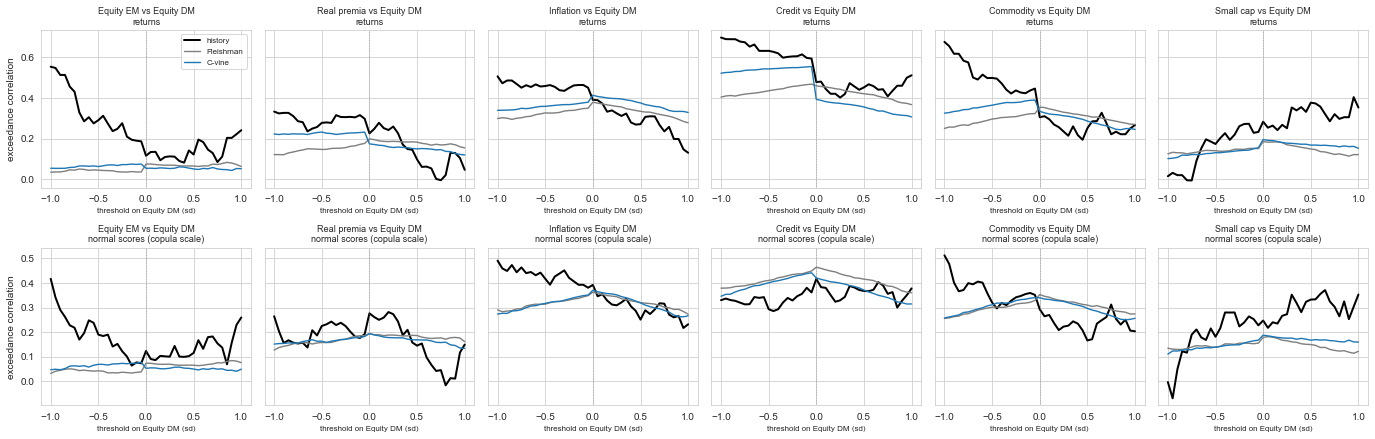

z = -1  z = 0  z = +1
Equity EM   returns       history      0.55   0.12    0.24
                          Fleishman    0.04   0.07    0.06
                          C-vine       0.05   0.05    0.05
            normal scores history      0.42   0.12    0.26
                          Fleishman    0.03   0.07    0.08
                          C-vine       0.05   0.05    0.05
Real premia returns       history      0.33   0.23    0.05
                          Fleishman    0.12   0.20    0.15
                          C-vine       0.22   0.17    0.12
            normal scores history      0.26   0.28    0.15
                          Fleishman    0.13   0.19    0.16
                          C-vine       0.15   0.19    0.13
Inflation   returns       history      0.51   0.39    0.13
                          Fleishman    0.30   0.38    0.28
                          C-vine       0.34   0.41    0.33
            normal scores history      0.49   0.39    0.23
                          Fleishman    0.29   0.36    0.27
                          C-vine       0.27   0.37    0.27
Credit      returns       history      0.70   0.48    0.51
                          Fleishman    0.40   0.46    0.37
                          C-vine       0.52   0.39    0.31
            normal scores history      0.33   0.42    0.38
                          Fleishman    0.38   0.46    0.36
                          C-vine       0.35   0.42    0.31
Commodity   returns       history      0.68   0.31    0.27
                          Fleishman    0.25   0.35    0.27
                          C-vine       0.33   0.33    0.25
            normal scores history      0.51   0.29    0.20
                          Fleishman    0.26   0.35    0.27
                          C-vine       0.26   0.34    0.26
Small cap   returns       history      0.02   0.28    0.35
                          Fleishman    0.12   0.19    0.12
                          C-vine       0.10   0.20    0.15
            normal scores history     -0.00   0.25    0.35
                          Fleishman    0.13   0.18    0.12
                          C-vine       0.11   0.19    0.16

In [13]:
base = "Equity DM"; others = [f for f in fm.factors if f != base]; z = np.round(np.arange(-1, 1.0001, 0.05), 3)
with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(2, len(others), figsize=(3.2 * len(others), 6.2), sharey="row")
    for j, f in enumerate(others):
        for row, (label, tf) in enumerate([("returns", lambda v: v), ("normal scores (copula scale)", normal_scores)]):
            ax = axes[row, j]
            for G, col, name in [(F, "black", "history"), (Ffl, "tab:grey", "Fleishman"), (Fcv, "tab:blue", "C-vine")]:
                ax.plot(z, exceedance_curve(tf(G[base]), tf(G[f]), z).values, color=col, lw=2 if name == "history" else 1.4, label=name)
            ax.axvline(0, color="grey", lw=0.6, ls=":"); ax.set_title(f"{f} vs {base}\n{label}", fontsize=9); ax.set_xlabel(f"threshold on {base} (sd)", fontsize=8)
    axes[0, 0].set_ylabel("exceedance correlation"); axes[1, 0].set_ylabel("exceedance correlation"); axes[0, 0].legend(fontsize=8)
    plt.tight_layout(); plt.show()
rows = {}
for f in others:
    for label, tf in [("returns", lambda v: v), ("normal scores", normal_scores)]:
        for G, name in [(F, "history"), (Ffl, "Fleishman"), (Fcv, "C-vine")]:
            e = exceedance_curve(tf(G[base]), tf(G[f]), [-1.0, 0.0, 1.0]); rows[(f, label, name)] = {"z = -1": e.iloc[0], "z = 0": e.iloc[1], "z = +1": e.iloc[2]}
pd.DataFrame(rows).T.round(2)

## Step 3: from factor scenarios to asset scenarios, and the checks

The factor tables of Step 2 are monthly, the frequency of the history: each
of the 25,000 rows is one synthetic month of the seven factor returns, in
decimals, and the rows have no time order, they are exchangeable draws (about
two thousand years of months, none of them following another). The factor
model turns each row into 68 asset returns for that month,

$$
r_j = \hat\alpha_j + \sum_{k \in \mathcal K_j} \hat\beta_{jk}\, f_k + e_j, \qquad e_j \sim \text{Johnson SU}(0, \hat\sigma_{e_j}, \hat\gamma_{1,e_j}, \hat\gamma_{2,e_j}),
$$

the residuals drawn independently. The first cell does it by hand for HYG on
two rows of the C-vine table, so the arithmetic is visible: a typical month
(the row closest to the factors' mean vector, in L2 distance on the returns)
and a bad month (the row whose Equity DM return is at its 5 percent quantile,
one month in twenty). For each, the factor values in percent and in standard
deviations of the factor, HYG's betas on its four allowed factors, their
products, and the systematic return; the residual, drawn from HYG's Johnson
SU with a standard deviation of 1.7 percent, is then added. The bad month is
where the C-vine differs from the Fleishman table: in a Student t month, a
fall in equity comes with moves of credit and real premia of comparable size,
and HYG inherits them through its betas.

The second cell does the mapping for every asset and every row of both tables
(`FactorModel.simulate`) and runs three checks. Means and volatilities against
the history: the mean is $\hat\alpha_j + \hat{\boldsymbol\beta}_j' \boldsymbol\mu_f$
and the variance $\hat{\boldsymbol\beta}_j' \boldsymbol\Sigma_f \hat{\boldsymbol\beta}_j + \hat\sigma_{e_j}^2$,
exact for both generators because both match $\boldsymbol\mu_f$ and
$\boldsymbol\Sigma_f$. Asset correlations against the history: the same RMSE
for both generators, the one of the implied matrix above. And the joint tails of
four assets against Equity DM: the exceedance profile, the probability that
both are in their lower 5 percent tail relative to independence, and the
co-kurtosis of notebook 01. Read the figure and the table together, and read
them honestly: the two generators' profiles are close to each other, and both
sit below the history's left side for EEM and HYG. The next cell says why.

In [14]:
a = "HYG"; fs = E[a]; b = fm.beta.loc[a, fs]
typical = ((Fcv - t.mean) ** 2).sum(axis=1).idxmin()                    # the month closest to the mean vector (L2 on the returns)
bad = (Fcv["Equity DM"] - Fcv["Equity DM"].quantile(0.05)).abs().idxmin()   # Equity DM at its 5 percent quantile
print(f"{a}: allowed factors {fs}; alpha {fm.alpha[a] * 100:.3f}% a month; residual sd {fm.resid_vol[a] * 100:.2f}% a month")
for label, i in [("a typical month (closest to the mean vector)", typical), ("a bad month (Equity DM at its 5 percent quantile)", bad)]:
    row = Fcv.loc[i, fs]
    tab = pd.DataFrame({"factor return (% in the month)": row * 100, "in standard deviations of the factor": row / t.vol[fs], "beta of HYG": b, "beta x factor (%)": (b * row) * 100})
    print(f"\n{label}: systematic return of HYG = alpha + sum(beta x factor) = {(fm.alpha[a] + (b * row).sum()) * 100:.2f}%")
    display(tab.round(2))

HYG: allowed factors ['Real premia', 'Inflation', 'Credit', 'Equity DM']; alpha 0.146% a month; residual sd 1.72% a month

a typical month (closest to the mean vector): systematic return of HYG = alpha + sum(beta x factor) = 0.37%


,factor return (% in the month),in standard deviations of the factor,beta of HYG,beta x factor (%)
Real premia,0.13,0.07,0.38,0.05
Inflation,-0.19,-0.14,-0.21,0.04
Credit,-0.22,-0.09,0.36,-0.08
Equity DM,0.58,0.12,0.36,0.21



a bad month (Equity DM at its 5 percent quantile): systematic return of HYG = alpha + sum(beta x factor) = -2.96%


,factor return (% in the month),in standard deviations of the factor,beta of HYG,beta x factor (%)
Real premia,-1.52,-0.84,0.38,-0.57
Inflation,-0.75,-0.54,-0.21,0.16
Credit,0.07,0.03,0.36,0.02
Equity DM,-7.46,-1.60,0.36,-2.71


In [15]:
Xfl = fm.simulate(Ffl, seed=1); Xcv = fm.simulate(Fcv, seed=1)
print("asset scenarios:", Xfl.shape, "and", Xcv.shape)
def rmse_corr(X): d = (X.corr().values - R.corr().values)[np.triu_indices(N, 1)]; return np.sqrt((d ** 2).mean())
print("asset correlations, RMSE against the history: Fleishman %.3f, C-vine %.3f" % (rmse_corr(Xfl), rmse_corr(Xcv)))
chk = pd.DataFrame({"mean, history (%)": R.mean() * 100, "mean, C-vine (%)": Xcv.mean() * 100, "vol, history (%)": R.std() * 100, "vol, Fleishman (%)": Xfl.std() * 100, "vol, C-vine (%)": Xcv.std() * 100})
print("largest absolute differences of volatility, C-vine vs history:", (chk["vol, C-vine (%)"] - chk["vol, history (%)"]).abs().nlargest(3).round(2).to_dict())
chk.loc[show].round(2)

asset scenarios: (25000, 68) and (25000, 68)
asset correlations, RMSE against the history: Fleishman 0.087, C-vine 0.087
largest absolute differences of volatility, C-vine vs history: {'KRE': 0.11, 'FXI': 0.1, 'EWP': 0.08}


,"mean, history (%)","mean, C-vine (%)","vol, history (%)","vol, Fleishman (%)","vol, C-vine (%)"
SPY,0.95,0.95,4.49,4.50,4.50
XLF,0.65,0.67,6.51,6.49,6.54
EWZ,0.61,0.64,9.51,9.53,9.55
TLT,0.32,0.32,4.08,4.10,4.13
HYG,0.44,0.45,2.95,2.97,2.98
GLD,0.88,0.85,5.05,5.07,5.09
XLU,0.71,0.76,4.29,4.30,4.28


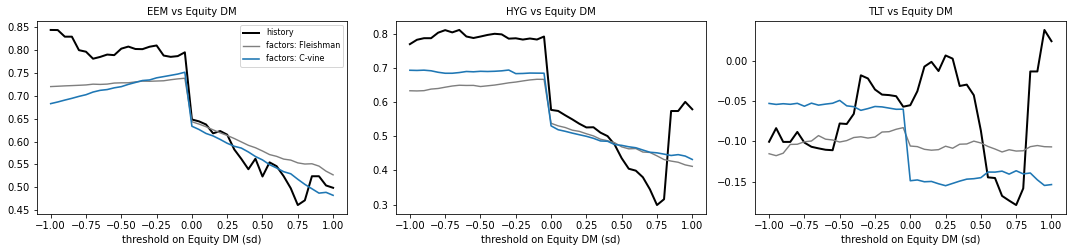

exceedance corr, z = -1  exceedance corr, z = +1  P(both in lower 5% tail) / 5%  co-kurtosis E[s^2 b^2]
EEM history                                0.84                     0.50                           0.70                    3.80
    factors: Fleishman                     0.72                     0.53                           0.63                    3.44
    factors: C-vine                        0.68                     0.48                           0.62                    3.73
HYG history                                0.77                     0.58                           0.70                    4.26
    factors: Fleishman                     0.63                     0.41                           0.62                    3.26
    factors: C-vine                        0.69                     0.43                           0.65                    3.83
TLT history                               -0.10                     0.02                           0.17                    1.69
    factors: Fleishman                    -0.12                    -0.11                           0.04                    1.37
    factors: C-vine                       -0.05                    -0.15                           0.08                    2.46
GLD history                                0.39                    -0.03                           0.17                    1.91
    factors: Fleishman                     0.12                     0.10                           0.13                    1.21
    factors: C-vine                        0.19                     0.08                           0.18                    1.61

In [16]:
z = np.round(np.arange(-1, 1.0001, 0.05), 3); base = "Equity DM"
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, a in zip(axes, ["EEM", "HYG", "TLT"]):
    hist = pd.concat([F[base], R[a]], axis=1)
    ax.plot(z, exceedance_curve(hist[base], hist[a], z).values, color="black", lw=2, label="history")
    ax.plot(z, exceedance_curve(Ffl[base], Xfl[a], z).values, color="tab:grey", lw=1.4, label="factors: Fleishman")
    ax.plot(z, exceedance_curve(Fcv[base], Xcv[a], z).values, color="tab:blue", lw=1.6, label="factors: C-vine")
    ax.set_title(f"{a} vs {base}", fontsize=10); ax.set_xlabel("threshold on Equity DM (sd)")
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()
def joint_tail(x, y, q=0.05): return float(np.mean((x <= x.quantile(q)) & (y <= y.quantile(q))) / q)
def cokurt(x, y): x = (x - x.mean()) / x.std(); y = (y - y.mean()) / y.std(); return float(np.mean(x**2 * y**2))
rows = {}
for a in ["EEM", "HYG", "TLT", "GLD"]:
    hist = pd.concat([F[base], R[a]], axis=1)
    for name, xf, xa in [("history", hist[base], hist[a]), ("factors: Fleishman", Ffl[base], Xfl[a]), ("factors: C-vine", Fcv[base], Xcv[a])]:
        e = exceedance_curve(xf, xa, [-1.0, 1.0])
        rows[(a, name)] = {"exceedance corr, z = -1": e.iloc[0], "exceedance corr, z = +1": e.iloc[1], "P(both in lower 5% tail) / 5%": joint_tail(xf, xa), "co-kurtosis E[s^2 b^2]": cokurt(xf, xa)}
pd.DataFrame(rows).T.round(2)

### Reading the check, and a case study

The figure surprises after notebook 02: the Fleishman route is not flat, and
the C-vine route is not much steeper. Two reasons. First, the slope of an
asset's profile is not tail dependence. An asset is a linear combination of
the factors, and its main term, Equity DM, is skewed: the copula of a sum of
skewed variables is not the copula of the factors, so EEM against Equity DM
slopes even on normal scores (0.68, 0.63, 0.53 for the Fleishman route) while
the Fleishman factor pairs themselves are flat on that scale, as the factor
figure showed. Both routes share the marginals and the betas, so both share
the slope. Second, the C-vine on the factors is symmetric: the symmetry test
found no factor pair significantly asymmetric on 230 months, so every
first-tree copula is a Student t or a Gaussian, and the C-vine adds
co-movement of sizes but no direction. The table shows exactly that: the
C-vine is closer to the history on the joint lower-tail probability and the
co-kurtosis (HYG 0.65 against 0.62, history 0.70; TLT co-kurtosis 2.5 against
1.4, history 1.7), which are what a symmetric copula carries, and no closer on
the left side of the profile.

The pair behind EEM is the one to look at, because the factor figure seems to
say the selection is wrong there: in the history, Equity EM's exceedance
correlation with Equity DM is 0.42 in Equity DM's bad months and 0.26 in its
good ones on the copula scale (0.55 and 0.24 on returns), and the vine gave it
a Student t whose profile is flat at 0.05. The next cell takes the pair apart.
It fits every family of the catalog to it by maximum likelihood, draws the
exceedance profile of each fitted copula against the empirical one with its
90 percent bootstrap band (300 resamples of the 230 months), and then repeats
the empirical profile at the weekly frequency, on an ETF proxy of the same
pair (EEM minus a 60/40 blend of SPY and EFA, against the blend), where there
are 1,000 observations instead of 230.

Equity EM vs Equity DM, 230 months, correlation 0.09; months with Equity DM below -1 sd: 29
empirical profile on the copula scale: z = -1 0.42 (bootstrap band [0.01, 0.65]), z = 0 0.12, z = +1 0.26


,parameters,BIC,profile RMSE vs empirical,z = -1,z = 0,z = +1
gumbel 180,1.06,2.320424,0.122046,0.098998,0.036823,0.03055
joe 180,1.08,2.296874,0.123987,0.117879,0.01659,0.015906
gumbel 0,1.07,1.516312,0.135995,0.022179,0.116427,0.131487
clayton 0,0.07,4.289298,0.141471,0.066152,0.01934,0.016802
gaussian 0,0.07,4.492257,0.146459,0.031487,0.047873,0.043574
clayton 180,0.12,2.696363,0.146795,0.006406,0.109521,0.116998
joe 0,1.11,0.7194,0.147992,0.004698,0.142658,0.172775
student 0,"0.03, 3.81",1.003047,0.159537,0.01769,0.028971,0.031009
clayton 90,0.00,5.438088,0.17565,0.001749,0.007527,0.013889
clayton 270,0.00,5.43811,0.17565,0.001748,0.007528,0.01389


daily returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/daily_cache_em.csv: 4858 days, 2007-06-04 to 2026-09-24
weekly ETF proxy, 1007 weeks, correlation 0.12: empirical z = -1 0.02 [-0.15, 0.16], z = 0 0.04, z = +1 -0.01 | BIC: Student t -45 (df 4.3), Gaussian -6


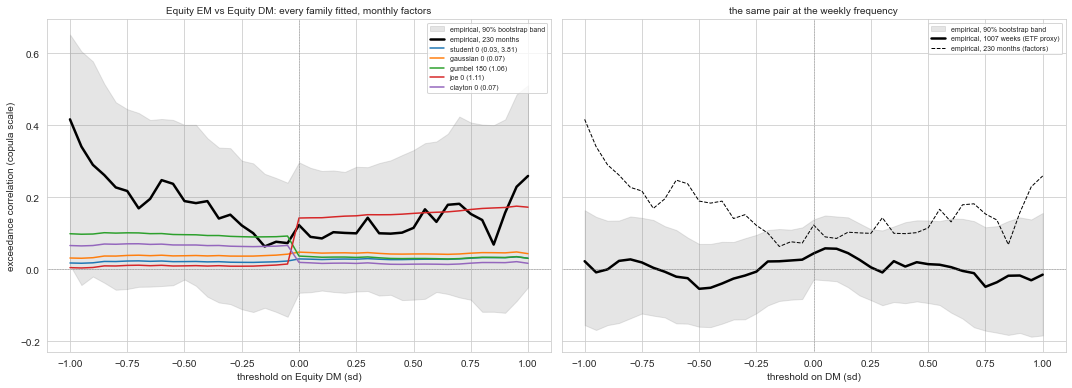

In [17]:
base, f = "Equity DM", "Equity EM"
x, y = F[base].values, F[f].values; n_m = len(x); U = pv.to_pseudo_obs(np.column_stack([x, y]))
z = np.round(np.arange(-1.0, 1.0001, 0.05), 3)
prof = lambda a, b: _ct.exceedance_correlation(np.asarray(a, float), np.asarray(b, float), z)
def band(x_, y_, n_boot=300, seed=0):
    rng_ = np.random.default_rng(seed); n_ = len(x_); B = np.empty((n_boot, len(z)))
    for b_ in range(n_boot):
        i = rng_.integers(0, n_, n_); B[b_] = prof(stats.norm.ppf(stats.rankdata(x_[i]) / (n_ + 1)), stats.norm.ppf(stats.rankdata(y_[i]) / (n_ + 1)))
    return np.nanquantile(B, 0.05, axis=0), np.nanquantile(B, 0.95, axis=0)
emp_m = prof(stats.norm.ppf(U[:, 0]), stats.norm.ppf(U[:, 1])); lo_m, hi_m = band(x, y)
cands = [(pv.BicopFamily.gaussian, 0), (pv.BicopFamily.student, 0)] + [(fam, r) for fam in (pv.BicopFamily.clayton, pv.BicopFamily.gumbel, pv.BicopFamily.joe) for r in (0, 90, 180, 270)]
rows, curves = {}, {}
for fam, rot in cands:
    b = _ct.fit_student_itau(U) if fam == pv.BicopFamily.student else pv.Bicop(fam, rot)
    if fam != pv.BicopFamily.student: b.fit(U)
    V = b.simulate(100000, seeds=[1, 2, 3, 4, 5]); c = prof(stats.norm.ppf(V[:, 0]), stats.norm.ppf(V[:, 1])); k = f"{fam.name} {rot}"; curves[k] = c
    rows[k] = {"parameters": ", ".join(f"{v:.2f}" for v in b.parameters.ravel()), "BIC": float(b.bic(U)), "profile RMSE vs empirical": float(np.sqrt(np.nanmean((c - emp_m) ** 2))), "z = -1": float(c[0]), "z = 0": float(c[20]), "z = +1": float(c[-1])}
tab = pd.DataFrame(rows).T; tab.iloc[:, 1:] = tab.iloc[:, 1:].astype(float); tab = tab.sort_values("profile RMSE vs empirical")
print(f"{f} vs {base}, {n_m} months, correlation {np.corrcoef(x, y)[0, 1]:.2f}; months with {base} below -1 sd: {int(((x - x.mean()) / x.std() < -1).sum())}")
print(f"empirical profile on the copula scale: z = -1 {emp_m[0]:.2f} (bootstrap band [{lo_m[0]:.2f}, {hi_m[0]:.2f}]), z = 0 {emp_m[20]:.2f}, z = +1 {emp_m[-1]:.2f}")
display(tab.round(3))
Dd = load_daily_returns(["SPY", "EFA", "EEM"], start="2007-06-01", cache=os.path.join(ROOT, "data", "daily_cache_em.csv"))
Pw = (1 + Dd).cumprod().resample("W-FRI").last().pct_change().dropna(); dm_w = 0.6 * Pw["SPY"] + 0.4 * Pw["EFA"]; em_w = Pw["EEM"] - dm_w
Uw = pv.to_pseudo_obs(np.column_stack([dm_w.values, em_w.values])); emp_w = prof(stats.norm.ppf(Uw[:, 0]), stats.norm.ppf(Uw[:, 1])); lo_w, hi_w = band(dm_w.values, em_w.values)
sw = _ct.fit_student_itau(Uw); gw = pv.Bicop(pv.BicopFamily.gaussian, 0); gw.fit(Uw)
print(f"weekly ETF proxy, {len(Uw)} weeks, correlation {np.corrcoef(dm_w, em_w)[0, 1]:.2f}: empirical z = -1 {emp_w[0]:.2f} [{lo_w[0]:.2f}, {hi_w[0]:.2f}], z = 0 {emp_w[20]:.2f}, z = +1 {emp_w[-1]:.2f} | BIC: Student t {sw.bic(Uw):.0f} (df {sw.parameters[1, 0]:.1f}), Gaussian {gw.bic(Uw):.0f}")
with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
    ax = axes[0]; ax.fill_between(z, lo_m, hi_m, color="grey", alpha=0.2, label="empirical, 90% bootstrap band"); ax.plot(z, emp_m, color="black", lw=2.5, label=f"empirical, {n_m} months")
    for j, k in enumerate(["student 0", "gaussian 0", "gumbel 180", "joe 0", "clayton 0"]): ax.plot(z, curves[k], lw=1.5, color=plt.get_cmap("tab10")(j), label=f"{k} ({rows[k]['parameters']})")
    ax.set_title(f"{f} vs {base}: every family fitted, monthly factors", fontsize=10); ax.set_xlabel(f"threshold on {base} (sd)"); ax.set_ylabel("exceedance correlation (copula scale)"); ax.legend(fontsize=7)
    ax = axes[1]; ax.fill_between(z, lo_w, hi_w, color="grey", alpha=0.2, label="empirical, 90% bootstrap band"); ax.plot(z, emp_w, color="black", lw=2.5, label=f"empirical, {len(Uw)} weeks (ETF proxy)")
    ax.plot(z, emp_m, color="black", lw=1, ls="--", label=f"empirical, {n_m} months (factors)"); ax.set_title("the same pair at the weekly frequency", fontsize=10); ax.set_xlabel("threshold on DM (sd)"); ax.legend(fontsize=7)
    for ax in axes: ax.axvline(0, color="grey", lw=0.6, ls=":"); ax.axhline(0, color="grey", lw=0.6, ls=":")
    plt.tight_layout(); plt.show()

Read it in three steps. The spike is not established: 0.42 on the left rests
on 29 months, and the bootstrap band at that point reaches down to zero. No
copula produces it anyway: at a correlation of 0.09 every family of the
catalog, fitted to the pair, gives at most 0.12 on the left (a Gumbel 180 at
theta 1.07 is next to independence), and a two-component mixture cannot do
better, because each component enters the left region in proportion to its
weight; the catalog has no shape that is strong in 29 months and absent in
the other 200. And with more data the spike is gone: on the weekly proxy,
1,000 observations of the same pair, the profile is flat within a few
hundredths of zero across the whole range, with a band a third as wide, while
the Student t beats the Gaussian by BIC by a wide margin. That is what the
automatic selection said on the monthly factors: near independence with some
co-movement of sizes, a Student t. The lesson for a reader of exceedance
plots is the one of notebook 01 in another form: a shape that 29 months draw
is not a target, and a family that reproduced it would be reproducing noise.
Where a manager believes an asymmetry on grounds the sample cannot show, the
next section imposes it.

## Step 3b: the manager's own mean and volatility for an asset

A manager rarely takes the sample mean of an asset as its expected return,
and often has a volatility assumption too. The factor model can honour both
for any listed asset without touching what the asset is. Under the model,

$$
\mathbb E[r_j] = \alpha_j + \boldsymbol\beta_j'\boldsymbol\mu_f, \qquad
\mathrm{Var}(r_j) = \underbrace{\boldsymbol\beta_j'\boldsymbol\Sigma_f\boldsymbol\beta_j}_{\text{systematic}} + \sigma_{e_j}^2 ,
$$

so a target mean $\mu_j^*$ is hit by resetting the alpha,
$\alpha_j^* = \mu_j^* - \boldsymbol\beta_j'\boldsymbol\mu_f$, and a target
volatility $\sigma_j^*$ by resetting the residual's scale,
$\sigma_{e_j}^{*2} = \sigma_j^{*2} - \boldsymbol\beta_j'\boldsymbol\Sigma_f\boldsymbol\beta_j$.
The betas are untouched, so the asset's dependence on the factors and on
every other asset keeps its structure; the residual keeps its skewness and
kurtosis, only its scale moves. The volatility target is feasible only if it
is at least the systematic volatility $\sqrt{\boldsymbol\beta_j'\boldsymbol\Sigma_f\boldsymbol\beta_j}$,
the part the betas impose: below it the method refuses and names the floor,
because reaching it would mean changing the exposures.

`FactorModel.with_targets` takes the assumptions as a dictionary or as a
table with one row per asset and the columns `mean` and `vol`, in annual
percent by default (a spreadsheet read with `pd.read_excel` or `pd.read_csv`
is such a table), a missing entry keeping the sample value. It returns a copy
of the model and a report per asset: the target and sample mean, the new
alpha, the target and sample volatility, the systematic volatility and the new
residual volatility. The cell sets four assets, one of them infeasible on
purpose, then simulates through the C-vine factor scenarios and checks that
the listed assets' means and volatilities are the targets and that the
others are unchanged.

In [18]:
assumptions = pd.DataFrame({"mean": [0.07, 0.03, 0.05, np.nan], "vol": [0.17, 0.14, 0.09, 0.06]}, index=["SPY", "TLT", "HYG", "EEM"])   # annual, as a spreadsheet would give them
print("the manager's table (annual):"); display(assumptions)
try:
    fm.with_targets(assumptions)
except ValueError as err:
    print("refused:", err)
assumptions.loc["EEM", "vol"] = 0.22                                    # above EEM's systematic volatility
fm_t = fm.with_targets(assumptions)
rep = fm_t.target_report.copy()
for c_ in ["target mean", "sample mean", "alpha"]: rep[c_] = rep[c_] * 1200
for c_ in ["target vol", "sample vol", "systematic vol", "sample resid vol", "new resid vol"]: rep[c_] = rep[c_] * np.sqrt(12) * 100
print("report, in percent a year:"); display(rep.round(2))
X_t = fm_t.simulate(Fcv, seed=1)
chk = pd.DataFrame({"target mean (%/yr)": assumptions["mean"] * 100, "simulated mean (%/yr)": X_t[assumptions.index].mean() * 1200,
                    "target vol (%/yr)": assumptions["vol"] * 100, "simulated vol (%/yr)": X_t[assumptions.index].std() * np.sqrt(12) * 100})
display(chk.round(2))
others = [a for a in R.columns if a not in assumptions.index]
print("other assets: max |difference| of simulated mean and vol against the untargeted model:", round(float((X_t[others].mean() - Xcv[others].mean()).abs().max() * 1200), 3), "%/yr and", round(float((X_t[others].std() - Xcv[others].std()).abs().max() * np.sqrt(12) * 100), 3), "%/yr")
print("correlation of SPY with TLT, targeted vs untargeted model:", round(X_t[["SPY", "TLT"]].corr().iloc[0, 1], 3), round(Xcv[["SPY", "TLT"]].corr().iloc[0, 1], 3))

the manager's table (annual):


,mean,vol
SPY,0.07,0.17
TLT,0.03,0.14
HYG,0.05,0.09
EEM,NaN,0.06


refused: with_targets: EEM: target volatility 0.0173 is below the systematic volatility 0.0591 implied by its betas; raise the target or change the exposures
report, in percent a year:


,target mean,sample mean,alpha,target vol,sample vol,systematic vol,sample resid vol,new resid vol
SPY,7.00,11.37,-0.07,17.0,15.55,15.02,4.03,7.96
TLT,3.00,3.83,5.86,14.0,14.14,13.30,4.80,4.38
HYG,5.00,5.27,1.48,9.0,10.26,8.35,5.96,3.35
EEM,6.51,6.51,-0.07,22.0,21.12,20.49,5.15,8.02


,target mean (%/yr),simulated mean (%/yr),target vol (%/yr),simulated vol (%/yr)
SPY,7.0,7.00,17.0,17.06
TLT,3.0,3.04,14.0,14.16
HYG,5.0,5.06,9.0,9.01
EEM,NaN,6.44,22.0,22.11


other assets: max |difference| of simulated mean and vol against the untargeted model: 0.0 %/yr and 0.0 %/yr
correlation of SPY with TLT, targeted vs untargeted model: -0.113 -0.123


Read the three tables. EEM's first target, a volatility of 6 percent a year,
is refused: its betas on the two equity factors and commodities imply a
systematic volatility of 20.5 percent, and no residual scale can bring the
total below it; the message names the floor, and the table is corrected to 22.
The report then gives, for each asset, what moved and what did not: SPY's
sample mean of 11.4 percent a year (a strong twenty years) becomes 7 through an
alpha of $-0.07$ percent a month; its target volatility of 17 against a
systematic 15.0 leaves a residual of 8.0 percent a year where the sample had
4.0; HYG's target of 9 against a sample 10.3 shrinks its residual from 6.0 to
3.4; TLT barely moves. The check on the simulated data shows the four assets
at their targets to the sampling precision of 25,000 months, and the other 64
assets untouched to the last digit. The correlation of SPY with TLT changes
slightly ($-0.113$ against $-0.123$) although the betas did not: the
covariance between two assets is unchanged, and a correlation is a covariance
divided by two volatilities, one of which the manager has just changed.

## Step 4: use, on portfolios of many assets

Two portfolios that a pairwise approach could not have priced: the equal-weight
portfolio of the whole universe, and a balanced portfolio, 60 percent equally
across the equity funds and 40 percent equally across the bond funds. VaR and
expected shortfall on the history, on each generator through the factors, and
under the normal, as in notebook 01, with the portfolio's skewness and
kurtosis.

In [19]:
def var_es(r, alpha=0.05):
    q = np.quantile(r, alpha); return -q, -r[r <= q].mean()
eq = [a for a in R.columns if a in groups["U.S. sectors"] + groups["U.S. size and style"] + groups["countries"]]
bd = [a for a in R.columns if a in groups["bonds"]]
w_eq = pd.Series(1.0 / N, index=R.columns)
w_bal = pd.Series(0.0, index=R.columns); w_bal[eq] = 0.6 / len(eq); w_bal[bd] = 0.4 / len(bd)
ports = {"equal weight, all assets": w_eq, "60/40, equity funds / bond funds": w_bal}
rows = {}
for pn, w in ports.items():
    rh = (R @ w).values; mu_p, sd_p = rh.mean(), rh.std()
    for name, X in [("history", None), ("factors: Fleishman", Xfl), ("factors: C-vine", Xcv)]:
        r = rh if X is None else (X @ w).values; v, e = var_es(r)
        rows[(pn, name)] = {"vol (%)": r.std() * 100, "skewness": stats.skew(r), "kurtosis": stats.kurtosis(r) + 3, "VaR 5% (%)": v * 100, "ES 5% (%)": e * 100}
    rows[(pn, "normal, same mean and vol")] = {"vol (%)": sd_p * 100, "skewness": 0.0, "kurtosis": 3.0, "VaR 5% (%)": -(mu_p + sd_p * stats.norm.ppf(0.05)) * 100, "ES 5% (%)": -(mu_p - sd_p * stats.norm.pdf(stats.norm.ppf(0.05)) / 0.05) * 100}
pd.DataFrame(rows).T.round(2)

vol (%)  skewness  kurtosis  VaR 5% (%)  ES 5% (%)
equal weight, all assets         history                       4.12     -0.63      5.30        6.45       9.26
                                 factors: Fleishman            4.07     -0.52      4.22        6.39       9.04
                                 factors: C-vine               4.08     -0.59      4.72        6.39       9.24
                                 normal, same mean and vol     4.12      0.00      3.00        6.10       7.82
60/40, equity funds / bond funds history                       3.18     -0.55      5.02        4.87       7.23
                                 factors: Fleishman            3.10     -0.55      4.27        4.83       6.86
                                 factors: C-vine               3.11     -0.64      4.94        4.87       7.04
                                 normal, same mean and vol     3.18      0.00      3.00        4.68       6.01

Read the table against notebooks 01 and 02. The tails of the portfolios come
from the seven factors' tails through the betas. For the equal-weight
portfolio the Fleishman route gives a kurtosis of 4.2 against the history's
5.3 and an expected shortfall of 9.04 against 9.26; the C-vine route, whose
first tree is five Student t copulas, gives 4.7 and 9.24, the history's
expected shortfall to two hundredths. For the balanced portfolio the C-vine
gives a kurtosis of 4.9 and an expected shortfall of 7.05 against 5.0 and
7.23, where the normal gives 6.01. Sixty-eight assets, and the tail of their
portfolio is set by six pair copulas on the factors.

The volatilities show the cost of the independence assumption: 4.08 against
4.12 for the equal-weight portfolio and 3.10 against 3.18 for the balanced
one. A portfolio's variance is the sum of its assets' covariances, and the
model has dropped the residual correlations, 0.15 on average, that the seven
factors do not explain, among the bond funds in particular. A specialized
factor would put the missing tenth of a percent back; the table shows what it
is worth.

### The manager's call: imposing a family on named pairs

Commodities, credit and inflation fell with equity in 2008, 2020 and 2022; a
manager who reads that as lower-tail dependence rather than as three months
of noise can impose it. `overrides` names the pairs and their copula, the
selection runs on every other pair as before, and the calibration keeps the
imposed families while it matches the correlations. Here a Gumbel rotated by
180 degrees, lower-tail dependence and no upper tail, on the three pairs
against Equity DM. The tables compare, for each factor, the history's profile
with the automatic vine's and the imposed vine's, then the profiles of two
assets that load on those factors, and the two portfolios' tails.

In [20]:
imposed = {("Inflation", "Equity DM"): ("gumbel", 180), ("Credit", "Equity DM"): ("gumbel", 180), ("Commodity", "Equity DM"): ("gumbel", 180)}
t0 = time.time(); cvi = CVineMarket(t, central="Equity DM", families="auto", overrides=imposed).fit(); print(f"fit with three imposed pairs: {time.time() - t0:.0f} s")
display(cvi.edges[cvi.edges["tree"] == 1])
Fi = cvi.simulate(25000, seed=1); Xi = fm.simulate(Fi, seed=1)
print("diagnostics, imposed vine:", cvi.diagnostics(Fi))
rows = {}
for f in [f_ for f_ in fm.factors if f_ != base]:
    for name, G in [("history", F), ("C-vine automatic", Fcv), ("C-vine imposed", Fi)]:
        e = exceedance_curve(G[base], G[f], [-1.0, 0.0, 1.0]); rows[(f, name)] = {"z = -1": e.iloc[0], "z = 0": e.iloc[1], "z = +1": e.iloc[2]}
print("factor profiles against Equity DM (returns)"); display(pd.DataFrame(rows).T.round(2))
rows = {}
for a in ["DBC", "XLE", "HYG", "EEM"]:
    hist = pd.concat([F[base], R[a]], axis=1)
    for name, xf, xa in [("history", hist[base], hist[a]), ("C-vine automatic", Fcv[base], Xcv[a]), ("C-vine imposed", Fi[base], Xi[a])]:
        e = exceedance_curve(xf, xa, [-1.0, 0.0, 1.0]); rows[(a, name)] = {"z = -1": e.iloc[0], "z = 0": e.iloc[1], "z = +1": e.iloc[2], "P(both in lower 5% tail) / 5%": joint_tail(xf, xa)}
print("asset profiles against Equity DM"); display(pd.DataFrame(rows).T.round(2))
rows = {}
for pn, w_ in [("equal weight, all assets", w_eq), ("60/40, equity funds / bond funds", w_bal)]:
    for name, X in [("history", R), ("C-vine automatic", Xcv), ("C-vine imposed", Xi)]:
        r = (X @ w_).values; v, e = var_es(r); rows[(pn, name)] = {"skewness": stats.skew(r), "kurtosis": stats.kurtosis(r) + 3, "VaR 5% (%)": v * 100, "ES 5% (%)": e * 100}
print("the two portfolios"); pd.DataFrame(rows).T.round(2)

fit with three imposed pairs: 82 s


,tree,edge,selected family,parameters
0,1,"Equity EM , Equity DM",student 0°,"rho=0.082, df=3.8"
1,1,"Real premia , Equity DM",student 0°,"rho=0.319, df=2.9"
2,1,"Inflation , Equity DM",gumbel 180°,theta=1.542
3,1,"Credit , Equity DM",gumbel 180°,theta=1.659
4,1,"Commodity , Equity DM",gumbel 180°,theta=1.494
5,1,"Small cap , Equity DM",gaussian 0°,theta=0.275


diagnostics, imposed vine: Diagnostics(n=25000, max |corr error|=0.0216, mean 2.3e-08, vol 1.1e-06, skew 1.1e-04, kurt 3.0e-03)
factor profiles against Equity DM (returns)


z = -1  z = 0  z = +1
Equity EM   history             0.55   0.12    0.24
            C-vine automatic    0.05   0.05    0.05
            C-vine imposed      0.04   0.06    0.03
Real premia history             0.33   0.23    0.05
            C-vine automatic    0.22   0.17    0.12
            C-vine imposed      0.22   0.18    0.12
Inflation   history             0.51   0.39    0.13
            C-vine automatic    0.34   0.41    0.33
            C-vine imposed      0.52   0.24    0.12
Credit      history             0.70   0.48    0.51
            C-vine automatic    0.52   0.39    0.31
            C-vine imposed      0.62   0.29    0.16
Commodity   history             0.68   0.31    0.27
            C-vine automatic    0.33   0.33    0.25
            C-vine imposed      0.49   0.22    0.12
Small cap   history             0.02   0.28    0.35
            C-vine automatic    0.10   0.20    0.15
            C-vine imposed      0.14   0.18    0.14

asset profiles against Equity DM


z = -1  z = 0  z = +1  P(both in lower 5% tail) / 5%
DBC history             0.68   0.30    0.26                           0.52
    C-vine automatic    0.32   0.33    0.24                           0.38
    C-vine imposed      0.49   0.22    0.11                           0.42
XLE history             0.67   0.51    0.56                           0.61
    C-vine automatic    0.48   0.42    0.33                           0.48
    C-vine imposed      0.57   0.37    0.28                           0.51
HYG history             0.77   0.58    0.58                           0.70
    C-vine automatic    0.69   0.53    0.43                           0.65
    C-vine imposed      0.71   0.50    0.40                           0.65
EEM history             0.84   0.65    0.50                           0.70
    C-vine automatic    0.68   0.63    0.48                           0.62
    C-vine imposed      0.67   0.64    0.46                           0.61

the two portfolios


skewness  kurtosis  VaR 5% (%)  ES 5% (%)
equal weight, all assets         history              -0.63      5.30        6.45       9.26
                                 C-vine automatic     -0.59      4.72        6.39       9.24
                                 C-vine imposed       -0.64      4.80        6.45       9.25
60/40, equity funds / bond funds history              -0.55      5.02        4.87       7.23
                                 C-vine automatic     -0.64      4.94        4.87       7.04
                                 C-vine imposed       -0.59      4.93        4.80       6.92

Read the three tables. The three imposed pairs keep their Gumbel through the
calibration (thetas 1.5 to 1.7, lower-tail coefficients $2 - 2^{1/\theta}$ of
0.4 to 0.5), the other pairs are as the selection left them, and the
correlations are still matched (largest error 0.022 against 0.05 allowed).
On the factors the left side is recovered: Inflation 0.52 against the
history's 0.51 (the automatic vine had 0.34), Commodity 0.49 against 0.68
(from 0.33), Credit 0.62 against 0.70 (from 0.52). The right side is not, and
that is the caveat of the choice: Credit and Commodity have both tails in the
history (0.51 and 0.27 at $z = +1$), and the Gumbel 180 has none on the right,
so the imposed vine puts 0.16 and 0.12 there. A family with two tails and a
stronger left one is what these pairs call for, and the catalog does not have
it; the Student t gave them symmetric tails, the Gumbel one tail. On the
assets the same trade appears where the factor loadings are large: DBC's
profile goes from flat (0.32, 0.33, 0.24) to 0.49, 0.22, 0.11 against the
history's 0.68, 0.30, 0.26, and its joint lower tail from 0.38 to 0.42
(history 0.52); XLE likewise; HYG and EEM barely move, their factors not
being among the imposed. The portfolios' tails hardly move either: 9.25
against 9.24 for the equal-weight expected shortfall, 6.92 against 7.04 for
the balanced one. Sixty-eight assets diversify a factor-level asymmetry away
in an unconditional tail; the imposed families matter for conditional
questions, what commodities and credit do given an equity crash, which is
where a manager asks them.

### A view on a factor reaches every asset

A view is a change of a factor's target, and the factor model carries it to
every asset that loads on that factor through its beta, and to no other. The
first view lowers Equity DM's expected excess return by 0.5 percent a month (6
percent a year) with everything else kept: each asset's expected return moves
by $\beta_{j,DM} \times (-0.005)$, which the table gives for the assets with
the largest equity betas and for four that have none by the exposure table,
and the balanced portfolio's distribution shifts by the weighted sum. The
second view sets the correlation between Equity DM and Real premia, $+0.31$ in
the sample, to $-0.30$: the diversification a balanced portfolio hopes for
from its bonds, asked at the factor level. Nothing changes for any single
asset, and every equity-bond pair in the universe changes at once, so the
balanced portfolio's volatility moves by exactly what the factor covariance
$\mathbf B\, \boldsymbol\Sigma_f\, \mathbf B' + \mathbf D$ implies, the
third column of the table. Both views run through the Fleishman generator,
which refits in a second; the C-vine accepts the same targets.

In [21]:
w = w_bal
t_view = Targets.from_history(F); t_view.mean["Equity DM"] -= 0.005
shift = fm.beta["Equity DM"] * (-0.005)
print("implied change of expected monthly return (%): the four largest equity betas, and four assets without an equity exposure")
display(pd.concat([shift.nsmallest(4), shift[["TLT", "TIP", "GLD", "DBC"]]]).mul(100).round(3).to_frame("change (%)").T)
X_view = fm.simulate(FleishmanMarket(t_view).fit().simulate(25000, seed=1), seed=1)
t_corr = Targets.from_history(F); t_corr.corr.loc["Equity DM", "Real premia"] = t_corr.corr.loc["Real premia", "Equity DM"] = -0.30
X_corr = fm.simulate(FleishmanMarket(t_corr).fit().simulate(25000, seed=1), seed=1)
def implied_port_vol(tg):
    Sf = np.outer(tg.vol, tg.vol) * tg.corr.values; S = B @ Sf @ B.T + D; return float(np.sqrt(w.values @ S @ w.values))
rows = {}
for name, X, tg in [("sample targets", Xfl, t), ("view: Equity DM mean -0.5% a month", X_view, t_view), ("view: corr(Equity DM, Real premia) = -0.30", X_corr, t_corr)]:
    r = (X @ w).values; v, e = var_es(r)
    rows[name] = {"corr(Equity DM, Real premia) target": tg.corr.loc["Equity DM", "Real premia"], "portfolio mean, simulated (%)": r.mean() * 100, "portfolio vol, implied by targets (%)": implied_port_vol(tg) * 100, "portfolio vol, simulated (%)": r.std() * 100, "VaR 5%, simulated (%)": v * 100, "ES 5%, simulated (%)": e * 100}
pd.DataFrame(rows).T.round(2)

implied change of expected monthly return (%): the four largest equity betas, and four assets without an equity exposure


,EWY,XLF,KBE,EWI,TLT,TIP,GLD,DBC
change (%),-0.667,-0.651,-0.643,-0.642,-0.0,-0.0,-0.0,-0.0


,"corr(Equity DM, Real premia) target","portfolio mean, simulated (%)","portfolio vol, implied by targets (%)","portfolio vol, simulated (%)","VaR 5%, simulated (%)","ES 5%, simulated (%)"
sample targets,0.31,0.56,3.11,3.10,4.83,6.86
view: Equity DM mean -0.5% a month,0.31,0.25,3.11,3.10,5.13,7.16
"view: corr(Equity DM, Real premia) = -0.30",-0.30,0.56,2.76,2.75,4.24,6.10


Read the two views. The mean view is a location shift, as in notebook 01:
each asset's expected return moves by its equity beta times $-0.5$ percent,
$-0.67$ for Korea and about $-0.65$ for financials, banks and Italy, and
exactly zero for TLT, TIP, gold and commodities, which the exposure table
keeps off the equity factor; the balanced portfolio's mean falls by 0.31
percent, its weighted equity beta times 0.5, and its VaR and ES rise by
exactly 0.30 (4.83 to 5.13, 6.86 to 7.16), the shape untouched. The
correlation view changes no asset and no mean, and moves the balanced
portfolio's volatility from 3.10 to 2.75 percent a month, the value the
factor covariance implies (3.11 to 2.76 in the third column, the check): an
11 percent reduction of risk from one number, the equity-bond correlation,
which in the sample was positive. The VaR falls from 4.83 to 4.24 and the ES
from 6.86 to 6.10, by the volatility's ratio, as the location-scale argument
of notebook 01 says they should when only the scale changes.

## Save

In [22]:
fm.save("factor_model.json"); cv.save("factor_market.json")
fm2 = FactorModel.load("factor_model.json"); print("betas and exposures reloaded:", np.allclose(fm2.beta.values, fm.beta.values), fm2.exposures == fm.exposures)
fm2.simulate(CVineMarket.load("factor_market.json").simulate(3, seed=2, accept=False), seed=2).iloc[:, :6].round(4)

betas and exposures reloaded: True True


,XLF,XLK,XLE,XLV,XLI,XLP
0,0.0299,-0.0102,-0.0223,0.0151,0.0421,-0.0340
1,0.0728,0.0546,0.0658,0.0738,0.0335,0.0161
2,-0.0742,-0.0796,-0.0961,-0.0827,-0.0656,-0.0189


## What this misses

The residual correlations that seven factors leave (banks, homebuilders) are
dropped; a specialized factor would keep them. And the factors are time
series. The scenarios of this notebook are one-period draws, exchangeable
across months, whereas a factor's history is not: the table applies the tests
of independence over time to the factors, on the series and on its squares.
Read the second and third columns: the squared returns are autocorrelated for
four of the seven factors, equity, real premia, inflation and credit, so a
large month is followed by large months, in either direction. One-period
scenarios cannot carry that, and paths made of independent draws, as in
notebook 01, would understate the risk over a horizon.

In [23]:
pd.DataFrame({f: iid_tests(F[f].values) for f in fm.factors}).T.round(3).rename(columns={"lb_z": "Ljung-Box p, returns", "lb_z2": "Ljung-Box p, squared returns", "arch_lm": "ARCH-LM p"})

,"Ljung-Box p, returns","Ljung-Box p, squared returns",ARCH-LM p
Equity DM,0.476,0.000,0.001
Equity EM,0.293,0.202,0.737
Real premia,0.993,0.000,0.008
Inflation,0.024,0.000,0.002
Credit,0.172,0.026,0.115
Commodity,0.270,0.155,0.065
Small cap,0.980,0.499,0.630


## What was learned, and what comes next

Seven factors carry the dependence of a universe of 68 assets: an exposure
table written from what each asset is, targets on the factors, both generators
on seven variables, assets by exposures plus an independent residual, and a
view on one factor reaching every asset that loads on it. The one assumption,
independent residuals, is checked; where it fails the answer is a fund per
index or a specialized factor.

**Notebook 04** takes one factor's history as what it is, a time series,
tests it, and introduces the models that describe its dynamics and the
generalized error they leave behind.